In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import numpy as np
import matplotlib as plt
from matplotlib.pyplot import plot, scatter


def find_data_file(filename, subdir='calibration'):
    search_paths = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd() / 'Data' / filename,
        Path.cwd() / 'Data' / subdir / filename,
    ]

    for base in [Path.cwd(), *Path.cwd().parents]:
        search_paths.extend([
            base / filename,
            base / 'Data' / filename,
            base / 'Data' / subdir / filename,
        ])

    for path in search_paths:
        if path.exists():
            return path

    raise FileNotFoundError(f"Could not find '{filename}' in the expected data folders.")

# vecchia analisi

In [2]:
# prendo path per tutti uguale
DATA_FILE = find_data_file('V_settings2.csv')
df_variap = pd.read_csv(DATA_FILE, sep=',', header=0, engine='python')
display(df_variap)

,p_tensione[V],g_tensione[V],p_count,g_count,pg_doppie,tempo[min],p_threshold[mV],g_threshold[mV]
0,728,875,4126,8163,3276,3,62,22
1,728,875,3304,8129,2573,3,69,22
2,728,875,2561,8133,2008,3,76,22
3,728,875,1897,7955,1467,3,83,22
4,728,875,1473,8095,1128,3,90,22
5,728,875,1268,8187,965,3,97,22
6,728,875,1230,5564,918,3,97,35
7,728,875,1508,5544,1146,3,90,35
8,728,875,1942,5599,1451,3,83,35
9,728,875,2652,5672,2035,3,76,35


In [3]:
DATA_FILE = find_data_file('V_settings3.csv')
df_variag = pd.read_csv(DATA_FILE, sep=',', header=0, engine='python')
display(df_variag)

,p_tensione[V],g_tensione[V],p_threshold[mV],g_threshold[mV],p_count,g_count,pg_doppie,tempo[min]
0,728,875,83,22,1897,7955,1467,3
1,728,875,83,35,1942,5599,1451,3
2,728,875,83,45,1944,4826,1388,3
3,728,875,83,55,1967,3765,1282,3
4,728,875,83,62,1981,2940,1169,3
5,728,875,83,69,1921,2154,995,3
6,728,875,83,76,1903,1693,853,3
7,728,875,83,83,1952,1293,712,3
8,728,875,83,118,1834,454,289,3
9,728,875,83,125,1849,353,223,3


In [4]:
df_22 = df_variap[df_variap['g_threshold[mV]'] == 22]
df_35 = df_variap[df_variap['g_threshold[mV]'] == 35]
df_45 = df_variap[df_variap['g_threshold[mV]'] == 45]
df_70 = df_variap[df_variap['g_threshold[mV]'] == 70]
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_22['p_threshold[mV]'], y=df_22['p_count'], mode='markers', name='g_threshold[mV] = 22'))
fig.add_trace(go.Scatter(x=df_35['p_threshold[mV]'], y=df_35['p_count'], mode='markers', name='g_threshold[mV] = 35'))
fig.add_trace(go.Scatter(x=df_22['p_threshold[mV]'], y=df_22['pg_doppie'], mode = 'markers', name='coinc g_threshold[mV] = 22'))
fig.add_trace(go.Scatter(x=df_35['p_threshold[mV]'], y=df_35['pg_doppie'], mode = 'markers', name='coinc g_threshold[mV] = 35'))
fig.add_trace(go.Scatter(x=df_45['p_threshold[mV]'], y=df_45['p_count'], mode='markers', name='g_threshold[mV] = 45'))
fig.add_trace(go.Scatter(x=df_45['p_threshold[mV]'], y=df_45['pg_doppie'], mode = 'markers', name='coinc g_threshold[mV] = 45'))
fig.add_trace(go.Scatter(x=df_70['p_threshold[mV]'], y=df_70['p_count'], mode='markers', name='g_threshold[mV] = 70', marker =dict(color = '#1A73E8')))
fig.update_layout(title= 'tensione vs thr', xaxis_title='p_threshold[mV]', yaxis_title='p_count')
fig.show()


In [5]:
df_45p = df_variag[df_variag['p_threshold[mV]'] == 83]
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_45p['g_threshold[mV]'], y=df_45p['g_count'], mode='markers', name='g_threshold[mV] = 45'))
fig.add_trace(go.Scatter(x=df_45['p_threshold[mV]'], y=df_45['p_count'], mode='markers', name='g_threshold[mV] = 45'))

In [6]:
fig = go.Figure()
# fig.add_trace(go.Scatter(x=df_22['p_threshold[mV]'], y=df_22['pg_doppie']/df_22['p_count'], mode='markers', name='coinc 22'))
# fig.add_trace(go.Scatter(x=df_35['p_threshold[mV]'], y=df_35['pg_doppie']/df_35['p_count'], mode='markers', name='coin 35'))
fig.add_trace(go.Scatter(x=df_45['p_threshold[mV]'], y=df_45['pg_doppie']/df_45['p_count'], mode='markers', name='coinc 45'))
# fig.add_trace(go.Scatter(x=df_70['p_threshold[mV]'], y=df_70['pg_doppie']/df_70['p_count'], mode='markers', name='coinc 70', marker =dict(color = '#1A73E8')))
fig.add_trace(go.Scatter(x = df_45p['g_threshold[mV]'], y = df_45p['pg_doppie']/df_45p['g_count'], mode='markers', name='coinc 45p'))


# nuova analisi

In [7]:
# prendo path per tutti uguale
DATA_FILE = find_data_file('ch_4-5.csv')
df_varia = pd.read_csv(DATA_FILE, sep=',', skiprows=0, engine='python')
display(df_varia)

,p_tensione[V],g_tensione[V],p_threshold[mV],g_threshold[mV],p_count,g_count,pg_doppie,gm_doppie,pgm_triple,m_tensione[V],m_threshold[mV],tempo[min]
0,780,950,141,120,1420.0,1548.0,683.0,NaN,NaN,NaN,NaN,3
1,780,950,253,153,128.0,815.0,51.0,NaN,NaN,NaN,NaN,3
2,780,950,200,183,418.0,466.0,131.0,NaN,NaN,NaN,NaN,3
3,780,950,151,209,1117.0,269.0,133.0,NaN,NaN,NaN,NaN,3
4,780,950,234,192,218.0,372.0,65.0,NaN,NaN,NaN,NaN,3
5,780,950,212,201,378.0,334.0,106.0,NaN,NaN,NaN,NaN,3
6,780,950,238,224,192.0,197.0,37.0,NaN,NaN,NaN,NaN,3
7,780,950,187,171,563.0,518.0,176.0,NaN,NaN,NaN,NaN,3
8,800,950,237,167,373.0,557.0,126.0,NaN,NaN,NaN,NaN,3
9,800,980,187,173,1088.0,1115.0,466.0,NaN,NaN,NaN,NaN,3


In [8]:
df_780p = df_varia[df_varia['p_tensione[V]'] == 780]
df_950g = df_varia[df_varia['g_tensione[V]'] == 950]
df_800p = df_varia[df_varia['p_tensione[V]'] == 800]
df_980g = df_varia[df_varia['g_tensione[V]'] == 980]
df_880p = df_varia[df_varia['p_tensione[V]'] == 880]
df_1050g = df_varia[df_varia['g_tensione[V]'] == 1050]

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_780p['p_threshold[mV]'], y=df_780p['p_count'], mode='markers', name='p_threshold[mV] = 780', error_y=dict(type='data', array=np.sqrt(df_780p['p_count']), visible=True)))
fig.add_trace(go.Scatter(x=df_950g['g_threshold[mV]'], y=df_950g['g_count'], mode='markers', name='g_threshold[mV] = 950', error_y=dict(type='data', array=np.sqrt(df_950g['g_count']), visible=True)))
fig.add_trace(go.Scatter(x=df_880p['p_threshold[mV]'], y=df_880p['p_count'], mode='markers', name='p_threshold[mV] = 880', error_y=dict(type='data', array=np.sqrt(df_880p['p_count']), visible=True)))
fig.add_trace(go.Scatter(x=df_1050g['g_threshold[mV]'], y=df_1050g['g_count'], mode='markers', name='g_threshold[mV] = 1050', error_y=dict(type='data', array=np.sqrt(df_1050g['g_count']), visible=True)))
# fig.add_trace(go.Scatter(x=df_800p['p_threshold[mV]'], y=df_800p['p_count'], mode='markers', name='p_threshold[mV] = 800', error_y=dict(type='data', array=np.sqrt(df_800p['p_count']), visible=True)))
# fig.add_trace(go.Scatter(x=df_980g['g_threshold[mV]'], y=df_980g['g_count'], mode='markers', name='g_threshold[mV] = 980', error_y=dict(type='data', array=np.sqrt(df_980g['g_count']), visible=True)))

fig.update_layout(
    xaxis_title='threshold [mV]',
    yaxis_title='count',
    yaxis_type= 'log'
)
fig.show()

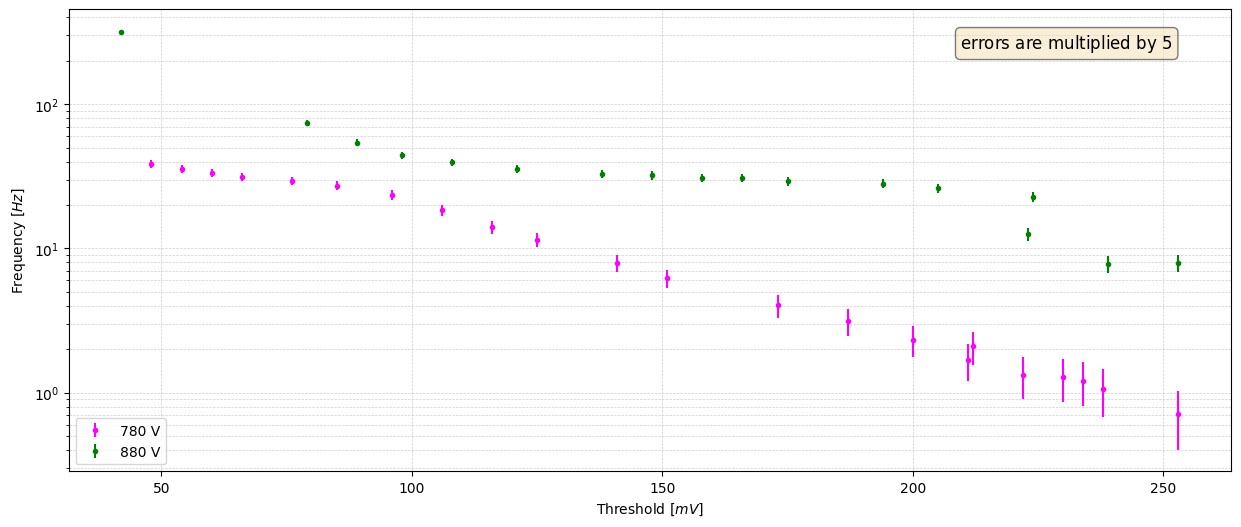

In [ ]:
error_multi = 5
time = 180
df_880_filtered = df_880p[(df_880p['p_count'] != 1635) & (df_880p['p_count'] != 1213)]

# Calculate mean and error for threshold 253
df_880_thr253 = df_880p[df_880p['p_threshold[mV]'] == 253]
mean_count_253 = df_880_thr253['p_count'].mean()
error_253 = np.sqrt(mean_count_253)

figsize = 15, 6

fig, (ax1) = plt.pyplot.subplots(1, figsize= figsize)
ax1.errorbar(df_780p['p_threshold[mV]'], df_780p['p_count']/time, yerr=error_multi*np.sqrt(df_780p['p_count'])/time, fmt='.', linestyle='none',
             label = '780 V', color = 'magenta')
ax1.errorbar(x=df_880_filtered['p_threshold[mV]'][:len(df_880_filtered['p_threshold[mV]'])-4], y=df_880_filtered['p_count'][:len(df_880_filtered['p_threshold[mV]'])-4]/time, yerr=error_multi*np.sqrt(df_880_filtered['p_count'][:len(df_880_filtered['p_threshold[mV]'])-4])/time, linestyle = '', fmt = '.',
             label = '880 V', color = 'green')
# Add threshold 253 mean point to ax1
ax1.errorbar(x=253, y=mean_count_253/time, yerr=error_multi*error_253/time, linestyle = '', fmt = '.', color = 'green')
ax1.legend()
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.set_yscale('log')
ax1.text(x=0.95, y=0.95, s=f'errors are multiplied by ${error_multi}$',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax1.set_ylabel('Frequency $[Hz]$')
ax1.set_xlabel('Threshold $[mV]$')
# plt.pyplot.savefig('partenope_th.pdf')


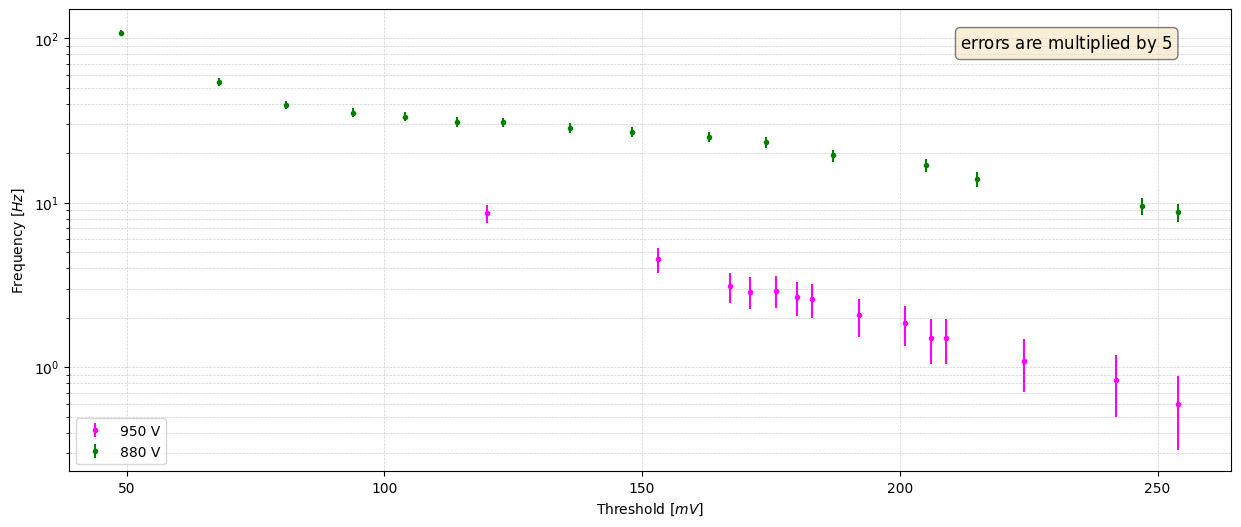

In [45]:
error_multi = 5
fig, ax2 = plt.pyplot.subplots(1, figsize = figsize)
ax2.errorbar(x=df_950g['g_threshold[mV]'], y=df_950g['g_count']/time, yerr=error_multi*np.sqrt(df_950g['g_count'])/time, fmt='.', linestyle='none',
             label = '950 V', color = 'magenta')
ax2.errorbar(x=df_1050g['g_threshold[mV]'][:len(df_1050g['g_threshold[mV]'])-5], y=df_1050g['g_count'][:len(df_1050g['g_threshold[mV]'])-5]/time,
              yerr=error_multi*np.sqrt(df_1050g['g_count'][:len(df_1050g['p_threshold[mV]'])-5])/time, linestyle = '', fmt = '.',
             label = '880 V', color = 'green')
ax2.legend()
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax2.set_yscale('log')
ax2.text(x=0.95, y=0.95, s=f'errors are multiplied by ${error_multi}$',
         transform=ax2.transAxes, ha='right', va='top',
         fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax2.set_ylabel('Frequency $[Hz]$')
ax2.set_xlabel('Threshold $[mV]$')
plt.pyplot.savefig('giunone_th.pdf')

# Triple vs Doppie

In [11]:
DATA_FILE = find_data_file('t_vs_d_p.csv')
df_tvd = pd.read_csv(DATA_FILE, sep=',', skiprows=0, engine='python')
display(df_tvd)

,p_tensione[V],g_tensione[V],m_tensione[V],p_threshold[mV],g_threshold[mV],m_threshold[mV],m_count,pg_doppie,pgm_triple,mg_doppie
0,880,1050,1200,178.0,166,40,NaN,4303.0,2978.0,3024.0
1,880,1050,1200,180.0,166,40,3468.0,4208.0,2302.0,2334.0
2,880,1050,1200,NaN,166,40,NaN,NaN,NaN,NaN
3,880,1050,1200,NaN,166,40,NaN,NaN,NaN,NaN


In [12]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_tvd['p_threshold[mV]'], y=df_tvd['mg_doppie'], mode='markers', name='mg_doppie', error_y=dict(type='data', array=np.sqrt(df_tvd['mg_doppie']), visible=True)))
fig.add_trace(go.Scatter(x=df_tvd['p_threshold[mV]'], y=df_tvd['pgm_triple'], mode='markers', name='pgm_triple', error_y=dict(type='data', array=np.sqrt(df_tvd['pgm_triple']), visible=True)))

fig.update_layout(title='doppie mg vs triple', xaxis_title='p_threshold[mV]', yaxis_title='count')
fig.show()

fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=df_tvd['p_threshold[mV]'], y=df_tvd['pgm_triple'] / df_tvd['mg_doppie'], mode='markers', name='ratio'))
fig1.update_layout(title='ratio', xaxis_title='p_threshold[mV]', yaxis_title='ratio t/d')
fig1.show()

# Minerva

In [13]:
DATA_FILE = find_data_file('txt_folder/t_vs_d.txt')
df = pd.read_csv(DATA_FILE, sep=' ', skiprows=0, engine='python')
DATA_FILE = find_data_file('ordine_pmg.csv')
df1 = pd.read_csv(DATA_FILE, sep = ',')
display(df1)

,p_tensione,g_tensione,m_tensione,p_thr,g_thr,m_thr,p_singola,m_singola,pg_doppia,pmg_tripla,mg_doppia,tempo[min]
0,850.0,1050.0,1200.0,178.0,166.0,24.0,5246.0,NaN,3734.0,2102.0,3165.0,3.0
1,850.0,1050.0,1200.0,178.0,166.0,30.0,5225.0,NaN,3630.0,1998.0,2955.0,3.0
2,850.0,1050.0,1200.0,178.0,166.0,35.0,5306.0,NaN,3655.0,2042.0,3025.0,3.0
3,850.0,1050.0,1200.0,178.0,166.0,40.0,5269.0,NaN,3620.0,2050.0,2981.0,3.0
4,850.0,1050.0,1200.0,178.0,166.0,50.0,5318.0,NaN,3683.0,2059.0,3039.0,3.0
5,850.0,1050.0,1200.0,178.0,166.0,60.0,5281.0,NaN,3577.0,1905.0,2865.0,3.0
6,850.0,1050.0,1200.0,178.0,166.0,70.0,5222.0,NaN,3570.0,1901.0,2878.0,3.0
7,850.0,1050.0,1200.0,178.0,166.0,102.0,5342.0,NaN,3572.0,1863.0,2731.0,3.0
8,850.0,1050.0,1200.0,178.0,166.0,162.0,5369.0,NaN,3587.0,1951.0,2904.0,3.0
9,850.0,1050.0,1240.0,178.0,166.0,24.0,5296.0,NaN,3704.0,2040.0,3136.0,3.0


In [14]:
x = df['m_th'][0:8]
y = df['s_m'][0:8]
x1 = df1['m_thr'][10:16]
y1 = df1['m_singola'][10:16]
nuova_c = [3759, 602, 3929, 7741, 15979, 14078, 24368, 1503, 4144, 5339] #alimentato a 1100 V, sempre 3 in per misura
nuova_thr = [184, 203, 166, 125, 78, 78, 39.5, 144, 175.8, 154.5]
x_sorted = np.concatenate((x, x1))
y_sorted = np.concatenate((y, y1))
idx = np.argsort(x_sorted)[::-1] 
x_sorted = x_sorted[idx]
y_sorted = y_sorted[idx]
# plot(x_sorted, y_sorted, )
plt.scatter(x, y)
plt.grid()
# plot(x1, y1)
# plt.scatter(x1, y1)


AttributeError: module 'matplotlib' has no attribute 'scatter'

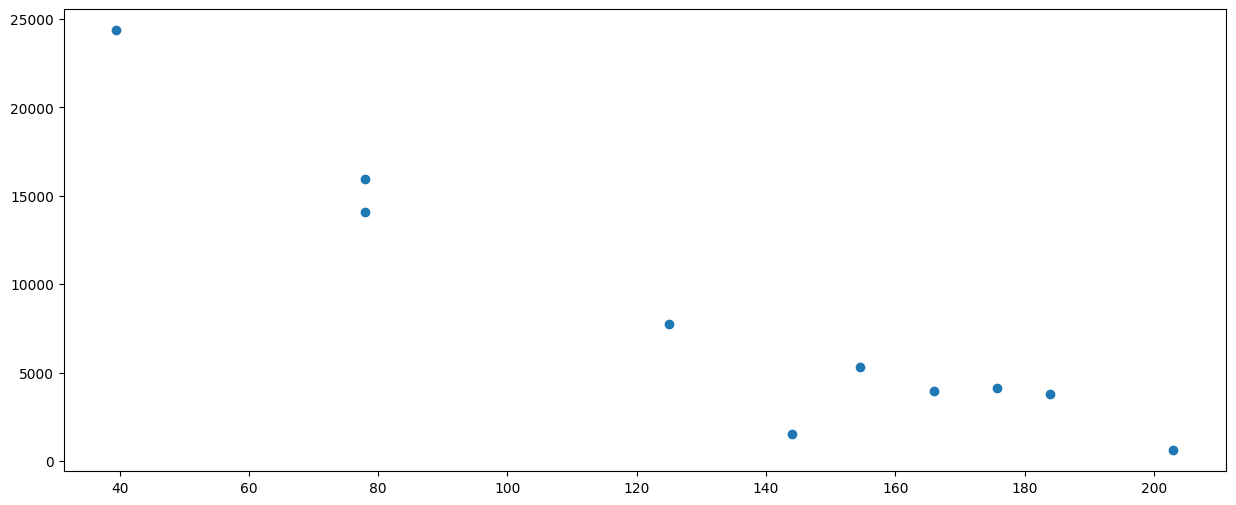

In [ ]:
plt.figure(figsize=(15, 6))
plt.scatter(nuova_thr, nuova_c)